In [1]:
# test-file-2b

# required packages
import czifile # to import a .czi file
from microfilm.microplot import microshow
import numpy as np
import matplotlib.pyplot as plt
from skimage.restoration import rolling_ball
from skimage import measure
from skimage.transform import rotate
from skimage import filters
from skimage.filters import gaussian

In [2]:
path = "/mnt/d/code/phd/image-analysis/synapse-counting/test-images-VLGUT1-PSD95/OE_Exp1_IHC_Exp1_HA-GPR37L1_555-VGLUT1_647-PSD95_63X_airyscan_1.8zoom_CA1_SO.czi"
image = czifile.imread(path)
image.shape

(1, 1, 2, 1, 1, 1000, 1000, 1)

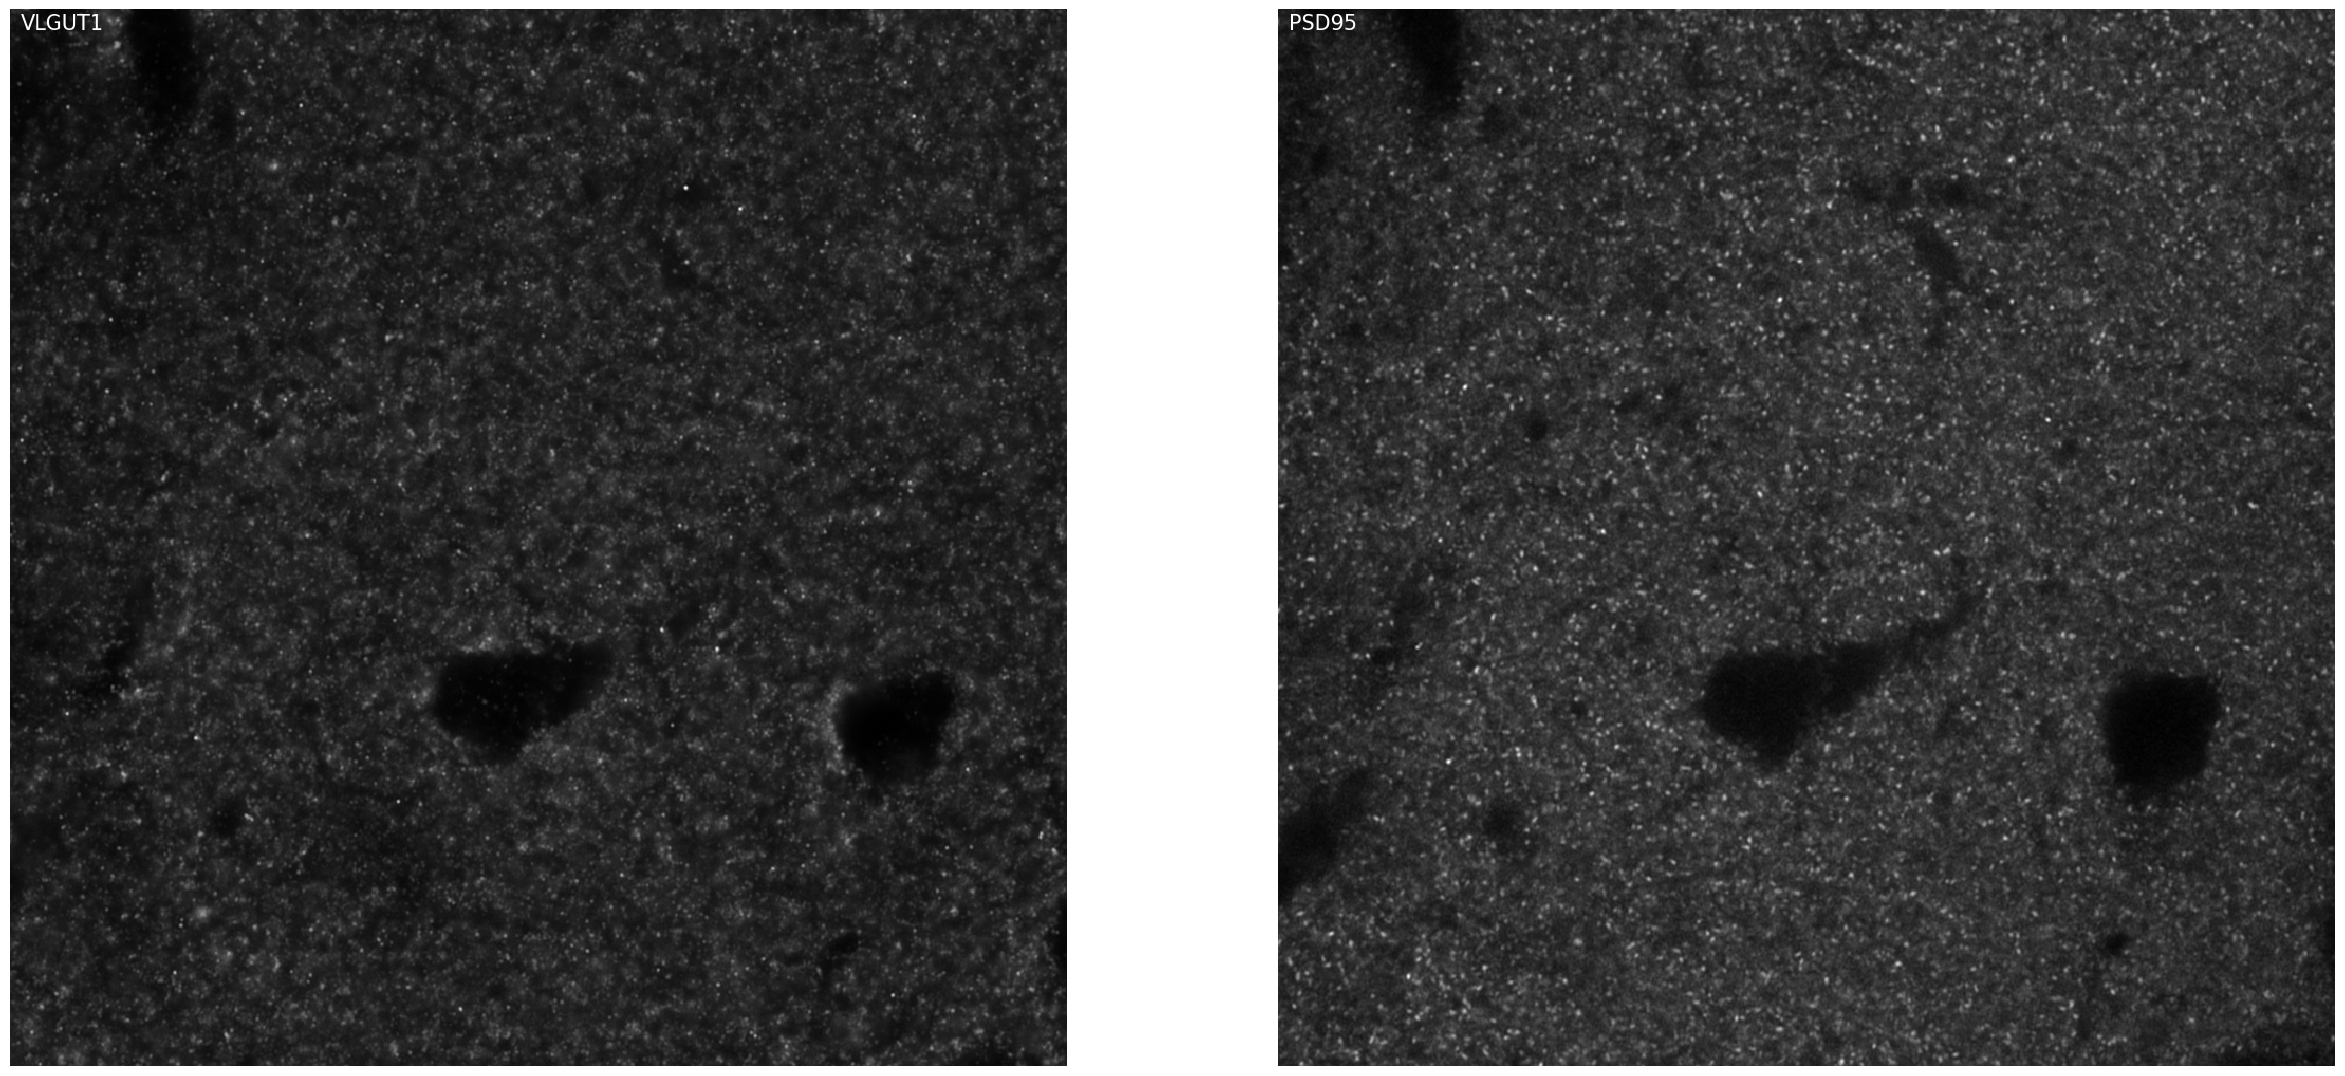

In [3]:
# getting rid of all the extra channels, splitting the channels and showing them one by one.
image_squeezed = np.squeeze(image)
image_squeezed.shape
vglut1 = image_squeezed[0,:,:]
psd95 = image_squeezed[1,:,:]

fig, axs = plt.subplots(1, 2, figsize = (30, 30))
microshow(vglut1, ax=axs[0], label_text = 'VLGUT1')
microshow(psd95, ax=axs[1], label_text = 'PSD95')

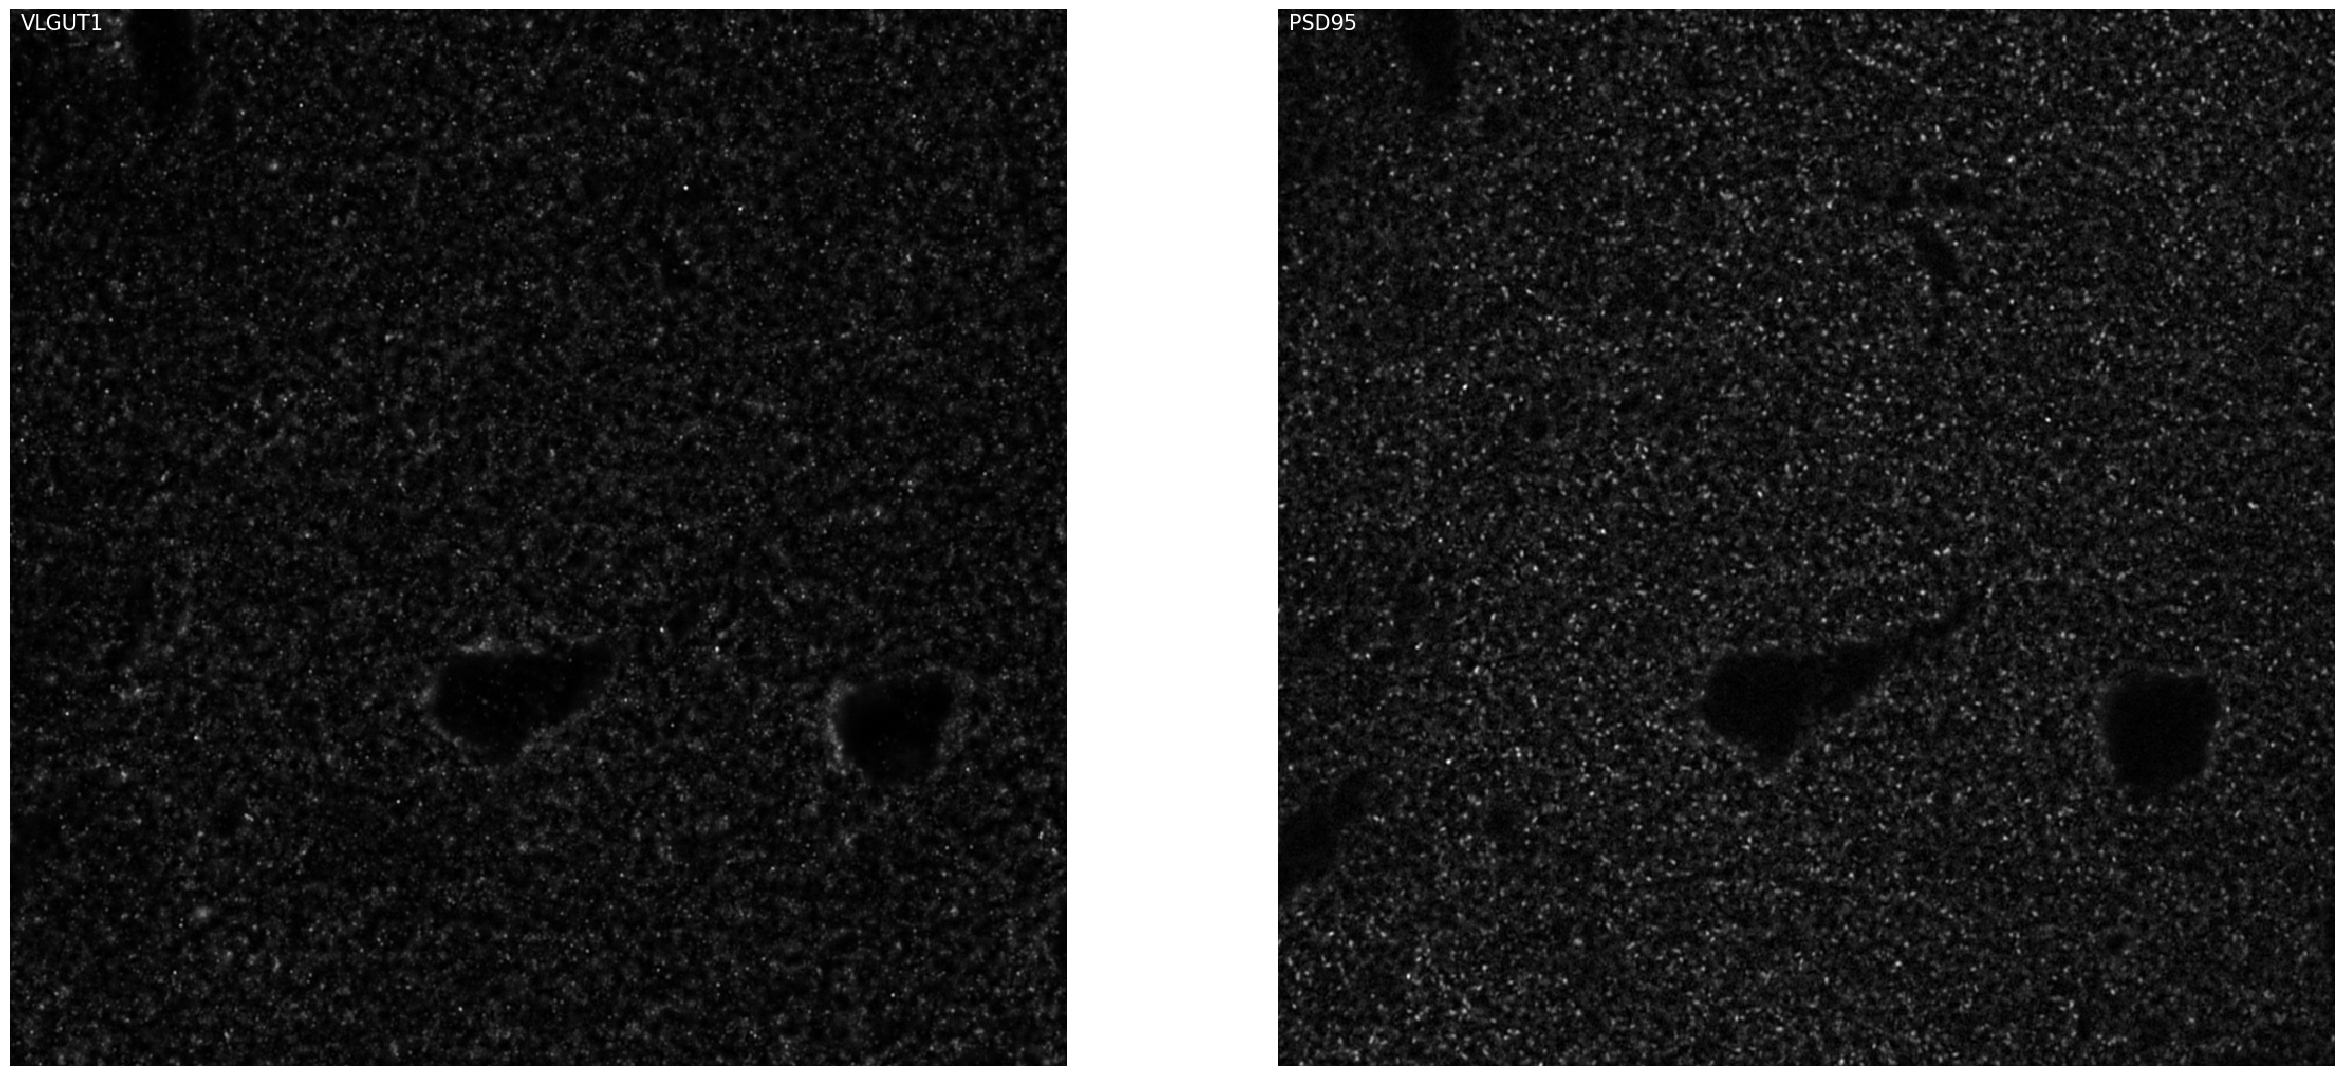

In [4]:
# now a preproccesing step, removal of background with rolling ball radius of 10x
background_vglut1 = rolling_ball(vglut1, radius = 10)
background_psd95 = rolling_ball(psd95, radius = 10)
vglut1_bs = vglut1 - background_vglut1
psd95_bs = psd95 - background_psd95

fig, axs = plt.subplots(1, 2, figsize = (30, 30))
microshow(vglut1_bs, ax=axs[0], label_text = 'VLGUT1')
microshow(psd95_bs, ax=axs[1], label_text = 'PSD95')

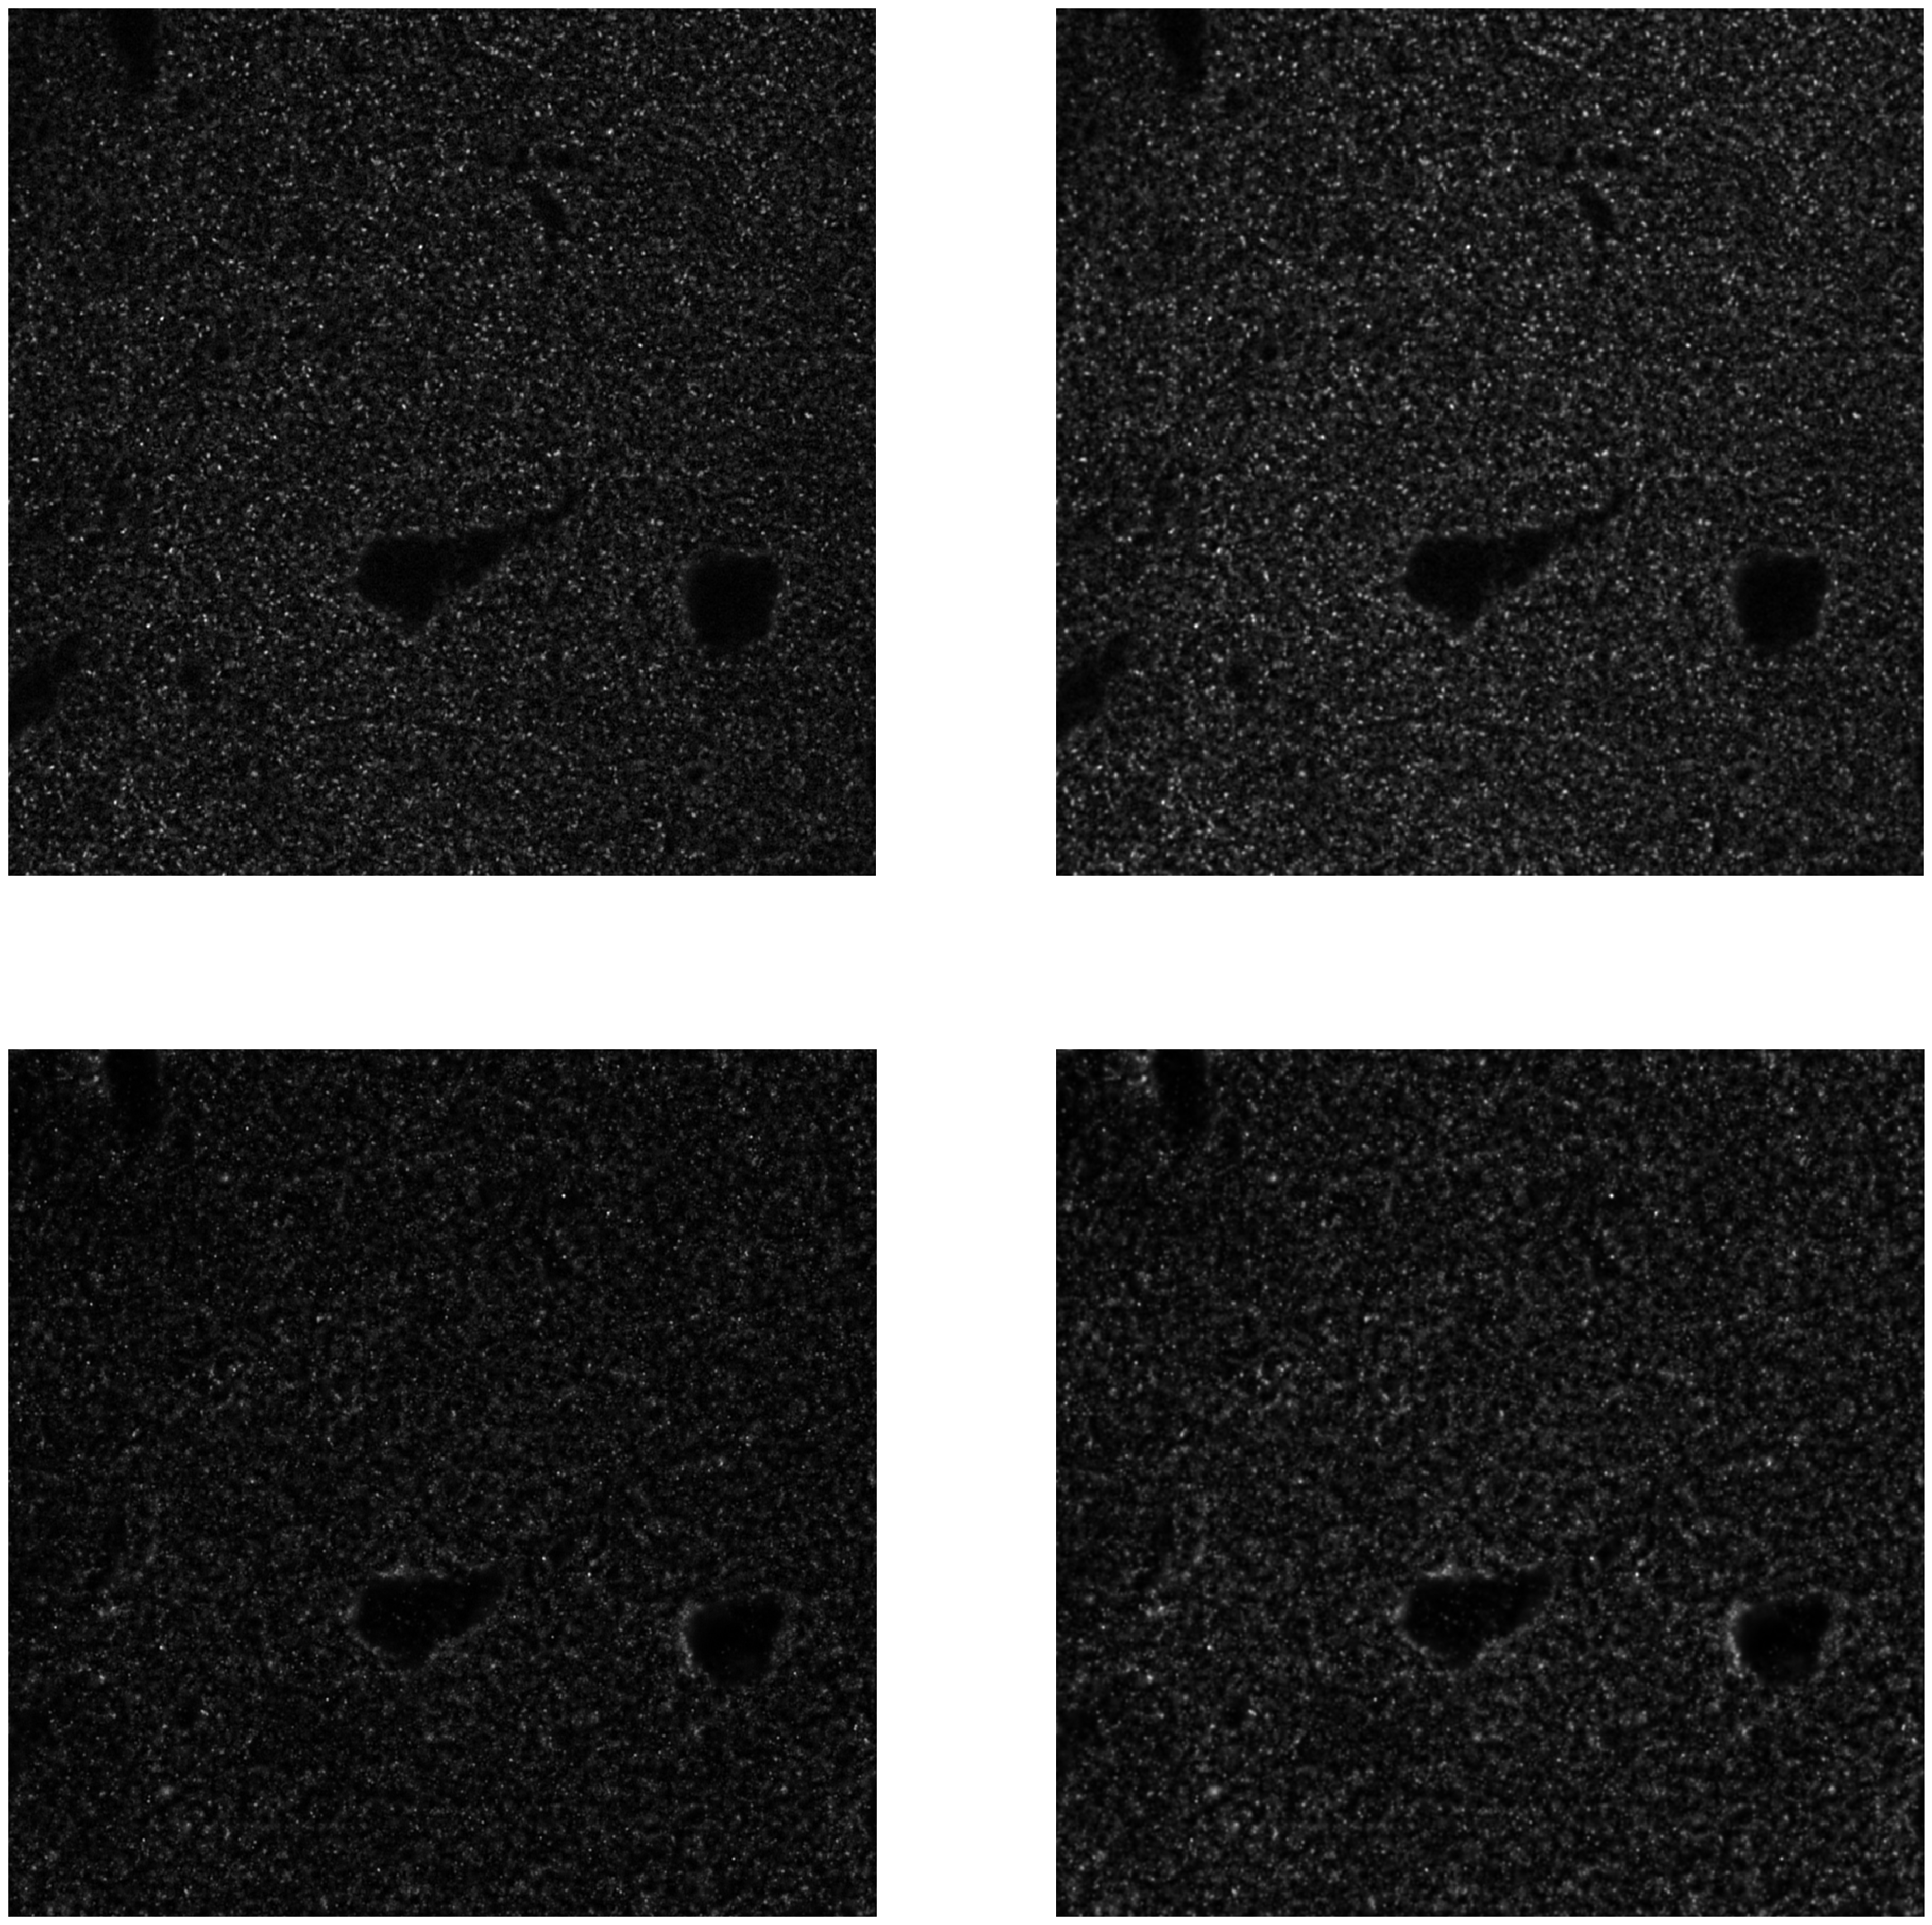

In [5]:
# for the thresholding, it is advised to perform a gaussian blur (in this case a light one with sigma 1)
psd95_pre = gaussian(psd95_bs, sigma=1, preserve_range=True)

vglut1_pre = gaussian(vglut1_bs, sigma=1, preserve_range=True)

fig, axs = plt.subplots(2, 2, figsize = (30, 30))
microshow(psd95_bs, ax=axs[0,0])
microshow(psd95_pre, ax=axs[0,1])
microshow(vglut1_bs, ax=axs[1,0])
microshow(vglut1_pre, ax=axs[1,1])

PCC_rot: -0.013753063500016382, p-val_rot: 4.839227437811444e-43
PCC: 0.2496312703745612, p-val: 0.0


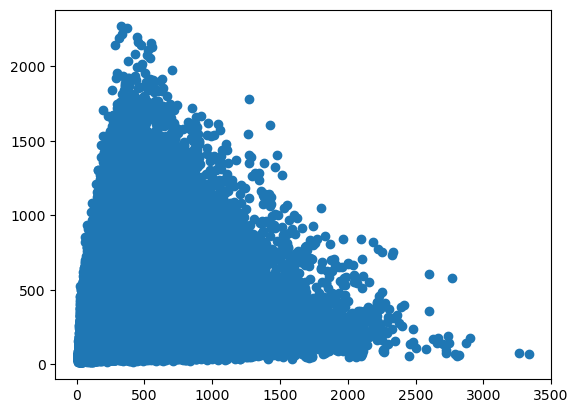

In [29]:
# pearsons correlation of colocalization - based on pixel intensities

# control (vglut1-psd95_rot)
psd95_pre_rot = rotate(psd95_pre, 90)
pcc_rot, pval_rot = measure.pearson_corr_coeff(vglut1_pre, psd95_pre_rot)
print(f"PCC_rot: {pcc_rot}, p-val_rot: {pval_rot}")
# actual (vglut1-psd95)
pcc, pval = measure.pearson_corr_coeff(vglut1_pre, psd95_pre)
print(f"PCC: {pcc}, p-val: {pval}")

# plotting the values

plt.figure()
plt.scatter(vglut1_pre, psd95_pre)


In [ ]:
# Van Steensel correlation - based on overlap of signal

# Costes randomization


78007 50663
0.3411944143801198 0.22159463401669094
391.7315917193198 368.91824481049116


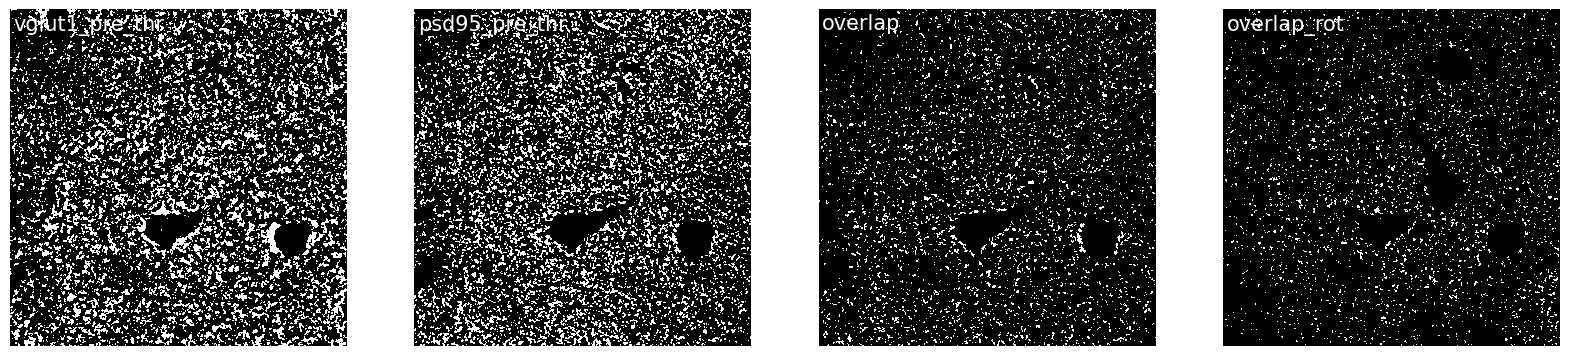

In [19]:
# Mander's overlap coefficient - based on binary images

# rotating the psd95 image as control
psd95_pre_rot = rotate(psd95_pre, 90)

# getting the threshold of each image
vglut1_threshold = filters.threshold_otsu(vglut1_pre)
psd95_threshold = filters.threshold_otsu(psd95_pre)
psd95_threshold_rot = filters.threshold_otsu(psd95_pre_rot)

# applying the threhold
vglut1_pre_thr = vglut1_pre >= vglut1_threshold
psd95_pre_thr = psd95_pre >= psd95_threshold
psd95_pre_rot_thr = psd95_pre_rot >= psd95_threshold_rot

# getting the overlap and nr of pixel that overlapped
overlap = vglut1_pre_thr & psd95_pre_thr
overlap_rot = vglut1_pre_thr & psd95_pre_rot_thr

overlap_pix = np.sum(overlap)
overlap_pix_rot = np.sum(overlap_rot)

# measuring the overlap coeff
overlap_coeff = measure.manders_overlap_coeff(vglut1_pre_thr, psd95_pre_thr)
overlap_coeff_rot = measure.manders_overlap_coeff(vglut1_pre_thr, psd95_pre_rot_thr)



# printing out the measurements
print(overlap_pix, overlap_pix_rot)
print(coloc_coeff, coloc_coeff_rot)
print(vglut1_threshold, psd95_threshold)

# showing the thresholded images and the overlap between the image and rotated images
fig, axs = plt.subplots(1, 4, figsize = (20, 20))
microshow(vglut1_pre_thr, ax=axs[0], label_text = 'vglut1_pre_thr')
microshow(psd95_pre_thr, ax=axs[1], label_text = 'psd95_pre_thr')
microshow(overlap, ax=axs[2], label_text = 'overlap')
microshow(overlap_rot, ax=axs[3], label_text = 'overlap_rot')

In [30]:
# getting the data into a dataframe and writing out the data into a csv

import os
import pandas as pd

# get the filename
name_of_file = os.path.splitext(os.path.basename(path))[0]
split_filename = name_of_file.split("_")

# get only the experimental parameters from the filename
index_nums = [0, 1, 2, 3, 10, 11] # the indexes of the elements that I would like to extract fro; the filename
desired_parts = [split_filename[val] for val in index_nums]
desired_filename = "_".join(desired_parts)

# making the df to output
d = {"image_name": desired_filename, 
     "pixels that overlap": overlap_pix, 
     "pixel that overlap - in rot cond": overlap_pix_rot,
     "pearsons corr coef": pcc,
     "pearsons corr coef - in rot cond": pcc_rot,
     "pearsons p value": pval,
     "pearsons p value - in rot cond": pval_rot,
     "manders overlap coef": overlap_coeff, 
     "manders overlap coef - in rot cond": overlap_coeff_rot,
     "vglut1_threshold": vglut1_threshold,
     "psd95_threshold": psd95_threshold}
df = pd.DataFrame.from_dict([d]).set_index("image_name")

# Writing the dataframe in a csv format into the a specific folder
output_filename = "threshold_values_" + desired_filename + ".csv"
output_path = "/mnt/d/code/phd/image-analysis/synapse-counting/output_data/" + output_filename
df.to_csv(output_path)